# Radial Basis Nearest Neighbor (RBNN)

- Giulia Monteiro Garrido (RA: 24010281)
- Mateus Andrade Antezana (RA: 24021000)
- Vitor Riki Araujo Furuta (RA: 24008775)

## Implementação do RBNN

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from random import shuffle, seed
from typing import Sequence
from ucimlrepo import fetch_ucirepo
from functools import wraps

SEMENTE = 10
SIGMAS_IRIS = [0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]
SIGMAS_ABALONE = [0.01, 0.025, 0.05, 0.075, 0.1, 0.15, 0.25, 0.35, 0.5, 1.0]
SIGMAS_EXTREMOS = [0.0001, 1000.0]

In [46]:
type numero = int | float

In [47]:
def tratamento_erros(funcao):
    @wraps(funcao)
    def funcao_interna(*args, **kwargs):
        try:
            return funcao(*args, **kwargs)
        except Exception as e:
            print(f"Erro na função {funcao.__name__}\nTipo: {e}")
            return None
    return funcao_interna

In [48]:
class Distancias:
    def _validar_vetores(self, A:Sequence[numero], B:Sequence[numero] | numero) -> None:
        if len(A) == 0:
            raise ValueError("Os vetores não podem estar vazios.")
        if not isinstance(B, (int, float)) and len(A) != len(B):
            raise ValueError("Os vetores precisam ter o mesmo tamanho.")

    @tratamento_erros
    def minkowski(self, A:Sequence[numero], B:Sequence[numero] | numero, p:int) -> numero:
        if p <= 0:
            raise ValueError("p deve ser maior que zero.")
        self._validar_vetores(A, B)
        soma = 0
        for i in range(len(A)):
            soma += abs(A[i] - (B if isinstance(B, (int, float)) else B[i])) ** p
        return soma ** (1 / p)

    @tratamento_erros
    def manhattan(self, A:Sequence[numero], B:Sequence[numero] | numero) -> numero:
        self._validar_vetores(A, B)
        soma = 0
        for i in range(len(A)):
            soma += abs(A[i] - (B if isinstance(B, (int, float)) else B[i]))
        return soma

    @tratamento_erros
    def euclidiana(self, A:Sequence[numero], B:Sequence[numero] | numero) -> numero:
        self._validar_vetores(A, B)
        soma = 0
        for i in range(len(A)):
            soma += (A[i] - (B if isinstance(B, (int, float)) else B[i])) ** 2
        return soma ** 0.5

In [49]:
dist = Distancias()

In [50]:
def pesos(x, X_treino, sigma:numero, distancia) -> np.ndarray:
    if sigma <= 0:
        raise ValueError(f"Sigma precisa ser maior que 0, {sigma} inserido.")

    distancias = np.array([distancia(x, xi) for xi in X_treino])
    formula = 1 / (sigma * np.sqrt(2 * np.pi))
    expoente = (distancias ** 2) / (2 * sigma ** 2)
    return formula * np.exp(-expoente)


def regressao(x, X_treino, y_treino, sigma:numero, distancia) -> numero:
    w = pesos(x, X_treino, sigma, distancia)

    if w.sum() == 0:
        distancias = np.array([distancia(x, xi) for xi in X_treino])
        return y_treino[np.argmin(distancias)]

    return np.sum(w * y_treino) / np.sum(w)


def classificacao(x, X_treino, y_treino, sigma:numero, distancia):
    w = pesos(x, X_treino, sigma, distancia)

    if w.sum() == 0:
        distancias = np.array([distancia(x, xi) for xi in X_treino])
        return y_treino[np.argmin(distancias)]

    y_treino = np.asarray(y_treino)
    votos = {classe: w[y_treino == classe].sum() for classe in np.unique(y_treino)}
    return max(votos, key=lambda classe: votos[classe])

In [51]:
class RBNNRegressor:
    def __init__(self, sigma:numero, distancia) -> None:
        self.sigma = sigma
        self.distancia = distancia

    def fit(self, X_treino, y_treino) -> None:
        self.X_treino = np.asarray(X_treino, dtype=float)
        self.y_treino = np.asarray(y_treino, dtype=float)

    def predict(self, X_teste) -> np.ndarray:
        return np.array([
            regressao(x, self.X_treino, self.y_treino, self.sigma, self.distancia)
            for x in X_teste
        ])

In [52]:
class RBNNClassifier:
    def __init__(self, sigma:numero, distancia) -> None:
        self.sigma = sigma
        self.distancia = distancia

    def fit(self, X_treino, y_treino) -> None:
        self.X_treino = np.asarray(X_treino, dtype=float)
        self.y_treino = np.asarray(y_treino)

    def predict(self, X_teste) -> np.ndarray:
        return np.array([
            classificacao(x, self.X_treino, self.y_treino, self.sigma, self.distancia)
            for x in X_teste
        ])

In [53]:
iris = sns.load_dataset("iris")

X_iris = iris.drop(columns="species").to_numpy()
y_iris = iris["species"].to_numpy()

print("formato:", iris.shape)
print("classes:", dict(zip(*np.unique(y_iris, return_counts=True))))
iris.head()

formato: (150, 5)
classes: {'setosa': np.int64(50), 'versicolor': np.int64(50), 'virginica': np.int64(50)}


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [54]:
seed(SEMENTE)
indices_iris = np.arange(len(X_iris))
shuffle(indices_iris)

treino_iris:int = int(0.7 * len(indices_iris))
deixado_pra_teste = round(1 - (treino_iris / len(indices_iris)), 2)

idx_treino = indices_iris[:treino_iris]
idx_teste = indices_iris[treino_iris:]

x_treino, x_teste = X_iris[idx_treino], X_iris[idx_teste]
y_treino, y_teste = y_iris[idx_treino], y_iris[idx_teste]

print(f"treino: {len(idx_treino)} | teste: {len(idx_teste)} ({deixado_pra_teste * 100}%)")

resultados_iris = {}
for sigma in SIGMAS_IRIS + SIGMAS_EXTREMOS:
    classificador = RBNNClassifier(sigma=sigma, distancia=dist.euclidiana)
    classificador.fit(x_treino, y_treino)
    resultados_iris[sigma] = float(np.mean(classificador.predict(x_teste) == y_teste))

melhor_sigma_iris = max(SIGMAS_IRIS + SIGMAS_EXTREMOS, key=lambda s: resultados_iris[s])
print("melhor sigma:", melhor_sigma_iris)

pd.DataFrame({"acurácia": resultados_iris}).rename_axis("sigma").sort_index()

treino: 105 | teste: 45 (30.0%)
melhor sigma: 0.25


,acurácia
sigma,
0.0001,0.955556
0.0500,0.955556
0.1000,0.955556
0.2500,0.977778
0.5000,0.977778
0.7500,0.955556
1.0000,0.955556
1.5000,0.933333
2.0000,0.911111


In [55]:
classificador = RBNNClassifier(sigma=melhor_sigma_iris, distancia=dist.euclidiana)
classificador.fit(x_treino, y_treino)
prever_iris = classificador.predict(x_teste)

acuracia:float = np.mean(prever_iris == y_teste)
classe_majoritaria = max(np.unique(y_treino), key=lambda c: (y_treino == c).sum())

print(f"Acurácia da iris (sigma = {melhor_sigma_iris}): {acuracia:.4f}")
print(f"Sempre chutar a classe majoritária ({classe_majoritaria}): {np.mean(y_teste == classe_majoritaria):.4f}")

classes = np.unique(y_iris)
pd.DataFrame(
    [[int(np.sum((y_teste == real) & (prever_iris == prev))) for prev in classes] for real in classes],
    index=[f"real {c}" for c in classes],
    columns=[f"previu {c}" for c in classes],
)

Acurácia da iris (sigma = 0.25): 0.9778
Sempre chutar a classe majoritária (virginica): 0.3111


,previu setosa,previu versicolor,previu virginica
real setosa,16,0,0
real versicolor,0,14,1
real virginica,0,0,14


In [56]:
abalone = fetch_ucirepo(id=1)

colunas = pd.DataFrame(abalone.data.features).drop(columns=["Sex"])
X_abalone = colunas.to_numpy(dtype=float)
y_abalone = pd.DataFrame(abalone.data.targets).to_numpy().ravel().astype(float)

print("atributos:", X_abalone.shape, "| alvo (Rings):", y_abalone.shape)
print(f"Rings: mínimo {y_abalone.min():.0f}, máximo {y_abalone.max():.0f}, média {y_abalone.mean():.2f}")

pd.DataFrame({"mínimo": X_abalone.min(axis=0), "máximo": X_abalone.max(axis=0)},
             index=colunas.columns).round(3)

atributos: (4177, 7) | alvo (Rings): (4177,)
Rings: mínimo 1, máximo 29, média 9.93


,mínimo,máximo
Length,0.075,0.815
Diameter,0.055,0.650
Height,0.000,1.130
Whole_weight,0.002,2.826
Shucked_weight,0.001,1.488
Viscera_weight,0.000,0.760
Shell_weight,0.002,1.005


In [57]:
seed(SEMENTE)
indices_abalone = np.arange(len(X_abalone))
shuffle(indices_abalone)

treino_abalone:int = int(0.7 * len(indices_abalone))
deixado_pra_teste = round(1 - (treino_abalone / len(indices_abalone)), 2)

idx_treino = indices_abalone[:treino_abalone]
idx_teste = indices_abalone[treino_abalone:]

x_treino_abalone, x_teste_abalone = X_abalone[idx_treino], X_abalone[idx_teste]
y_treino_abalone, y_teste_abalone = y_abalone[idx_treino], y_abalone[idx_teste]

print(f"treino: {len(idx_treino)} | teste: {len(idx_teste)} ({deixado_pra_teste * 100}%)")

variacao_teste = np.sum((y_teste_abalone - y_teste_abalone.mean()) ** 2)

resultados_abalone = {}
for sigma in SIGMAS_ABALONE + SIGMAS_EXTREMOS:
    regressor = RBNNRegressor(sigma=sigma, distancia=dist.euclidiana)
    regressor.fit(x_treino_abalone, y_treino_abalone)
    fit_abalone = regressor.predict(x_teste_abalone) - y_teste_abalone
    resultados_abalone[sigma] = {
        "MAE": float(np.mean(np.abs(fit_abalone))),
        "RMSE": float(np.sqrt(np.mean(fit_abalone ** 2))),
        "R2": float(1 - np.sum(fit_abalone ** 2) / variacao_teste),
    }

melhor_sigma_abalone = min(SIGMAS_ABALONE + SIGMAS_EXTREMOS,
                           key=lambda s: resultados_abalone[s]["RMSE"])
print("melhor sigma:", melhor_sigma_abalone)

pd.DataFrame(resultados_abalone).T.rename_axis("sigma").sort_index().round(4)

treino: 2923 | teste: 1254 (30.0%)
melhor sigma: 0.05


,MAE,RMSE,R2
sigma,,,
0.0001,2.0407,2.9627,0.1262
0.0100,1.8206,2.6791,0.2854
0.0250,1.5669,2.2627,0.4903
0.0500,1.5869,2.2357,0.5024
0.0750,1.6526,2.3153,0.4663
0.1000,1.7152,2.3873,0.4326
0.1500,1.7972,2.4805,0.3875
0.2500,1.8874,2.5755,0.3396
0.3500,1.9410,2.6374,0.3075


In [58]:
regressor = RBNNRegressor(sigma=melhor_sigma_abalone, distancia=dist.euclidiana)
regressor.fit(x_treino_abalone, y_treino_abalone)
prever_abalone = regressor.predict(x_teste_abalone)

fit_abalone = prever_abalone - y_teste_abalone
fit_media = y_treino_abalone.mean() - y_teste_abalone

mae = np.mean(np.abs(fit_abalone))
rmse = np.sqrt(np.mean(fit_abalone ** 2))

print(f"MAE: {mae:.4f}\nRMSE: {rmse:.4f}")

pd.DataFrame({
    f"RBNN (sigma = {melhor_sigma_abalone})": {
        "MAE": mae,
        "RMSE": rmse,
        "R2": 1 - np.sum(fit_abalone ** 2) / variacao_teste,
    },
    "referência: média do treino": {
        "MAE": np.mean(np.abs(fit_media)),
        "RMSE": np.sqrt(np.mean(fit_media ** 2)),
        "R2": 1 - np.sum(fit_media ** 2) / variacao_teste,
    },
}).T.round(4)

MAE: 1.5869
RMSE: 2.2357


,MAE,RMSE,R2
RBNN (sigma = 0.05),1.5869,2.2357,0.5024
referência: média do treino,2.3137,3.1705,-0.0007


## Estudo do desvio padrão σ

Base escolhida foi o Abalone. São 4.177 amostras o que deixa as métricas estáveis.

As faixas de σ testadas são diferentes nas duas bases porque os atributos estão na escala original: as distâncias do Abalone são bem menores que as da Iris, então a gaussiana também é mais estreita.

In [59]:
QUATRO_VALORES = {
    0.0001: "extremamente pequeno",
    0.05: "intermediário",
    0.25: "intermediário",
    1000.0: "extremamente alto",
}

pd.DataFrame([
    {"sigma": sigma,
     "faixa": faixa,
     "MAE": resultados_abalone[sigma]["MAE"],
     "RMSE": resultados_abalone[sigma]["RMSE"],
     "R2": resultados_abalone[sigma]["R2"]}
    for sigma, faixa in QUATRO_VALORES.items()
]).set_index("sigma").round(4)

,faixa,MAE,RMSE,R2
sigma,,,,
0.0001,extremamente pequeno,2.0407,2.9627,0.1262
0.0500,intermediário,1.5869,2.2357,0.5024
0.2500,intermediário,1.8874,2.5755,0.3396
1000.0000,extremamente alto,2.3137,3.1705,-0.0007


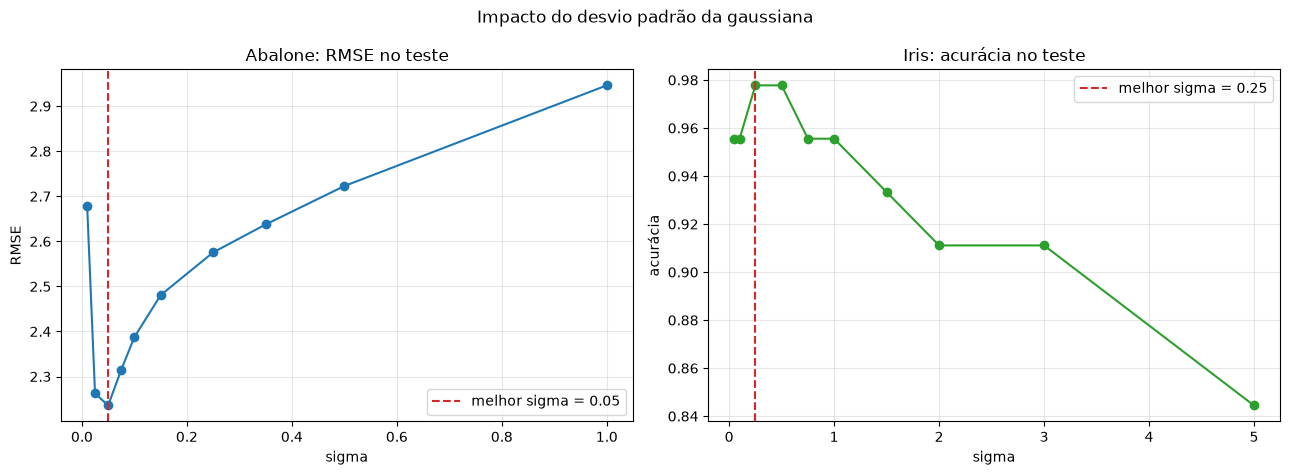

In [60]:
figura, eixos = plt.subplots(1, 2, figsize=(13, 4.8))

eixos[0].plot(SIGMAS_ABALONE, [resultados_abalone[s]["RMSE"] for s in SIGMAS_ABALONE],
              marker="o", color="#1f77b4")
eixos[0].axvline(melhor_sigma_abalone, color="#d62728", linestyle="--",
                 label=f"melhor sigma = {melhor_sigma_abalone}")
eixos[0].set_title("Abalone: RMSE no teste")
eixos[0].set_xlabel("sigma")
eixos[0].set_ylabel("RMSE")
eixos[0].legend()
eixos[0].grid(alpha=0.3)

eixos[1].plot(SIGMAS_IRIS, [resultados_iris[s] for s in SIGMAS_IRIS],
              marker="o", color="#2ca02c")
eixos[1].axvline(melhor_sigma_iris, color="#d62728", linestyle="--",
                 label=f"melhor sigma = {melhor_sigma_iris}")
eixos[1].set_title("Iris: acurácia no teste")
eixos[1].set_xlabel("sigma")
eixos[1].set_ylabel("acurácia")
eixos[1].legend()
eixos[1].grid(alpha=0.3)

figura.suptitle("Impacto do desvio padrão da gaussiana")
figura.tight_layout()
plt.show()

Os dois extremos exigidos, σ = 0,0001 e σ = 1000, ficam fora do gráfico. Se entrassem,
espremeriam toda a parte interessante da curva num cantinho. Eles estão na tabela dos quatro
valores e são analisados logo abaixo.

In [61]:
regressor = RBNNRegressor(sigma=0.0001, distancia=dist.euclidiana)
regressor.fit(x_treino_abalone, y_treino_abalone)
prever_sigma_minimo = regressor.predict(x_teste_abalone)

vizinho_mais_proximo = np.array([
    y_treino_abalone[np.argmin([dist.euclidiana(x, xi) for xi in x_treino_abalone])]
    for x in x_teste_abalone
])

print("sigma = 0.0001")
print("previsões idênticas às do vizinho mais próximo?",
      np.array_equal(prever_sigma_minimo, vizinho_mais_proximo))
print(f"RMSE com sigma = 0.0001: {np.sqrt(np.mean((prever_sigma_minimo - y_teste_abalone) ** 2)):.4f}")
print(f"RMSE do vizinho mais próximo: {np.sqrt(np.mean((vizinho_mais_proximo - y_teste_abalone) ** 2)):.4f}")

regressor = RBNNRegressor(sigma=1000.0, distancia=dist.euclidiana)
regressor.fit(x_treino_abalone, y_treino_abalone)
prever_sigma_maximo = regressor.predict(x_teste_abalone)

print("\n sigma = 1000")
print(f"desvio padrão das  : {prever_sigma_maximo.std():.6f}")
print(f"valor previsto: {prever_sigma_maximo.mean():.4f}")
print(f"média de Rings no treino: {y_treino_abalone.mean():.4f}")
print(f"RMSE com sigma = 1000: {np.sqrt(np.mean((prever_sigma_maximo - y_teste_abalone) ** 2)):.4f}")
print(f"RMSE prevendo sempre a média: {np.sqrt(np.mean(fit_media ** 2)):.4f}")

sigma = 0.0001
previsões idênticas às do vizinho mais próximo? True
RMSE com sigma = 0.0001: 2.9627
RMSE do vizinho mais próximo: 2.9627

 sigma = 1000
desvio padrão das  : 0.000001
valor previsto: 9.9593
média de Rings no treino: 9.9593
RMSE com sigma = 1000: 3.1705
RMSE prevendo sempre a média: 3.1705


In [62]:
amostra = x_teste_abalone[:100]
vizinhanca = {}

for sigma in [0.0001, 0.05, 0.25, 1.0, 1000.0]:
    quantidades = []
    for x in amostra:
        w = pesos(x, x_treino_abalone, sigma, dist.euclidiana)
        if w.sum() == 0:
            quantidades.append(1)
            continue
        ordenados = np.sort(w)[::-1]
        acumulado = np.cumsum(ordenados) / ordenados.sum()
        quantidades.append(int(np.searchsorted(acumulado, 0.90) + 1))

    vizinhanca[sigma] = {
        "vizinhos p/ 90% do peso": round(float(np.mean(quantidades)), 1),
        "% do treino": round(100 * float(np.mean(quantidades)) / len(x_treino_abalone), 1),
    }

print("conjunto de treino:", len(x_treino_abalone), "pontos")
pd.DataFrame(vizinhanca).T.rename_axis("sigma")

conjunto de treino: 2923 pontos


,vizinhos p/ 90% do peso,% do treino
sigma,,
0.0001,1.0,0.0
0.0500,164.6,5.6
0.2500,965.7,33.0
1.0000,2329.5,79.7
1000.0000,2631.0,90.0


### O impacto de σ

O melhor valor foi σ = 0,05 (menor RMSE). Com ele o modelo erra em média 1,59 anéis (MAE), tem RMSE 2,24 e R² 0,50, ou seja, explica cerca de metade da variação de `Rings`. Comparando com os extremos, o RMSE cai 24,5% em relação ao σ muito pequeno (2,9627) e 29,5% em relação ao σ muito grande (3,1705).

O σ controla quantos vizinhos realmente contam na hora de prever. O peso de cada vizinho é $w_i = \exp(-d_i^2 / 2\sigma^2)$: quanto maior o σ, mais devagar o
peso cai conforme a distância aumenta, então mais vizinhos entram na conta. A tabela abaixo mostra quantos vizinhos juntam 90% do peso total:

| σ | vizinhos que somam 90% do peso | fração do treino |
|---:|---:|---:|
| 0,0001 | 1 | 0,0% |
| 0,05 | 165 | 5,6% |
| 0,25 | 966 | 33,0% |
| 1,0 | 2330 | 79,7% |
| 1000 | 2631 | 90,0% |

σ muito pequeno (0,0001): o RBNN vira um KNN com k = 1.

A gaussiana fica tão estreita que só o vizinho mais próximo tem peso de verdade. O peso de todos os outros fica tão pequeno que o computador arredonda para zero. O código confirma isso: as previsões saem iguais, uma por uma, às de um KNN com k = 1 escrito separadamente, e os dois dão o mesmo RMSE de 2,9627.

O problema é que a previsão passa a depender de uma única amostra do treino. Se essa amostra for esquisita, a previsão vai junto. No Abalone isso pesa bastante, porque dois moluscos de medidas parecidas podem ter números de anéis bem diferentes.

σ muito grande (1000): o RBNN vira uma média simples.

Aqui acontece o contrário. O σ é tão maior que qualquer distância que todos os pesos ficam praticamente iguais. Como todo mundo pesa o mesmo, a previsão vira a média de todos os `Rings` do treino, o mesmo número para qualquer entrada. O código mostra isso: o desvio padrão das previsões cai para 0,000001, ou seja, é uma constante, e essa constante é 9,9593, exatamente a média do treino. O RMSE fica igual ao de simplesmente chutar a média (3,1705) e o R² vai a zero: o modelo ignora completamente as medidas do molusco.

σ no meio: o equilíbrio.

Entre os dois extremos está o ponto certo. A gaussiana fica estreita o bastante para dar mais peso a quem está perto, mas larga o bastante para juntar vários vizinhos e diluir o azar de uma amostra ruim. Com σ = 0,05 são cerca de 165 vizinhos, só 5,6% do treino.

- σ pequeno = muita variância. A previsão muda muito dependendo de qual amostra caiu perto.
- σ grande = muito viés. A previsão é sempre a mesma e erra de forma sistemática.

De σ = 0,05 para σ = 0,25 a vizinhança pula de 165 para 966 vizinhos e o RMSE piora 13,2%.

Errar o σ para baixo é menos ruim do que errar para cima. No pior caso do lado pequeno (RMSE 2,9627) o modelo ainda usa as medidas do molusco. No lado grande (RMSE 3,1705) ele joga as medidas fora. Ou seja, o pior KNN com k = 1 ainda é melhor do que chutar a média.

O valor 0,05 vale só para o Abalone. Como não mudamos a escala dos dados, o σ depende do tamanho dos números de cada base. No Abalone as distâncias são pequenas (mediana perto de 0,58), então a gaussiana precisa ser estreita. Na Iris, medida em centímetros, as distâncias são maiores e o melhor σ foi 0,25. É o mesmo comportamento, só que em outra escala.

## Conclusão

Fizemos o RBNN em duas classes separadas, `RBNNClassifier` e `RBNNRegressor`. As duas recebem o desvio padrão da gaussiana escolhido pelo usuário e usam o mesmo cálculo de pesos e a mesma família de distâncias.

| Base | Tarefa | σ escolhido | Resultado no teste | Chute trivial |
|---|---|---|---|---|
| Iris | classificação | 0,25 | acurácia 0,978 (44 de 45) | 0,311 (sempre a classe mais comum) |
| Abalone | prever `Rings` | 0,05 | MAE 1,59 · RMSE 2,24 · R² 0,50 | MAE 2,31 · RMSE 3,17 · R² 0,00 |

A conclusão principal é sobre o σ: ele não é um detalhe de ajuste fino, ele decide qual algoritmo o RBNN vira. Quando o σ é muito pequeno, o modelo vira um KNN com k = 1. Quando é muito grande, vira uma média simples que ignora os dados. Testamos os dois casos e os números bateram exatamente com essas duas contas feitas à parte, então não é só teoria. O σ que serve está numa faixa curta no meio, onde os dois efeitos se equilibram.